In [9]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'task0 (1).ipynb', 'drive', 'sample_data']


In [10]:
from google.colab import files

uploaded = files.upload()

Saving dataset_Class_Society_and_Social_Evolution.xls to dataset_Class_Society_and_Social_Evolution.xls
Saving dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.xls to dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.xls
Saving dataset_Class3_Crime_and_Justice_Charles_Dickens.xls to dataset_Class3_Crime_and_Justice_Charles_Dickens.xls
Saving dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.xls to dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.xls
Saving dataset_Class3_Imperialism_and_Colonialism_Charles_Dickens.xls to dataset_Class3_Imperialism_and_Colonialism_Charles_Dickens.xls
Saving dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.xls to dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.xls
Saving dataset_Crime_and_Justice.xls to dataset_Crime_and_Justice.xls
Saving dataset_Human_Class_Society_and_Social_Evolution.xls to dataset_Human_Class_Society_and_Social_Evolution.xls
Saving dataset_Human_Cri

In [5]:
import glob

files = glob.glob("*.xls") + glob.glob("*.csv")

print("Total files:", len(files))

for f in files:
    print(f)

Total files: 15
dataset_Class_Society_and_Social_Evolution.xls
dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.xls
dataset_Human_Class_Society_and_Social_Evolution.xls
dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.xls
dataset_Human_Human_Nature_and_Morality.xls
dataset_Human_Imperialism_and_Colonialism.xls
dataset_Scientific_Discovery_and_Technology.xls
dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.xls
dataset_Human_Scientific_Discovery_and_Technology.xls
dataset_Human_Crime_and_Justice.xls
dataset_Human_Nature_and_Morality.xls
dataset_Class3_Crime_and_Justice_Charles_Dickens.xls
dataset_Crime_and_Justice.xls
dataset_Class3_Imperialism_and_Colonialism_Charles_Dickens.xls
dataset_Imperialism_and_Colonialism.xls


In [6]:
import pandas as pd
import glob

files = glob.glob("*.xls")

dfs = []

for file in files:
    print("Reading:", file)
    try:
        df = pd.read_excel(file, engine="xlrd")
        dfs.append(df)
    except Exception as e:
        print("ERROR:", file)
        print(e)
        break

Reading: dataset_Class_Society_and_Social_Evolution.xls
ERROR: dataset_Class_Society_and_Social_Evolution.xls
Unsupported format, or corrupt file: Expected BOF record; found b'Topic,Pa'


In [7]:
import pandas as pd
import glob

files = glob.glob("*.xls")

dfs = []

for file in files:
    df = pd.read_csv(file)   # <-- read_csv, not read_excel
    dfs.append(df)

dataset = pd.concat(dfs, ignore_index=True)

print(dataset.shape)
dataset.head()

(750, 3)


,Topic,Paragraph,Class
0,"Class, Society, and Social Evolution",The emergence of distinct social classes has b...,AI_Normal
1,"Class, Society, and Social Evolution",Social evolution is intricately linked to the ...,AI_Normal
2,"Class, Society, and Social Evolution",The concept of social evolution is deeply inte...,AI_Normal
3,"Class, Society, and Social Evolution","Class, as a fundamental component of societal ...",AI_Normal
4,"Class, Society, and Social Evolution",Historical shifts in economic systems have con...,AI_Normal


In [8]:
print(dataset["Class"].value_counts())

Class
AI_Normal                      250
AI_Stylized_Charles_Dickens    250
Human                          250
Name: count, dtype: int64


In [9]:
dataset["Label"] = dataset["Class"].apply(
    lambda x: 0 if x == "Human" else 1
)

dataset[["Class","Label"]].head()

,Class,Label
0,AI_Normal,1
1,AI_Normal,1
2,AI_Normal,1
3,AI_Normal,1
4,AI_Normal,1


In [10]:
dataset.groupby("Class")["Label"].value_counts()

,,count
Class,Label,
AI_Normal,1,250
AI_Stylized_Charles_Dickens,1,250
Human,0,250


In [22]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.5 MB/s eta 0:00:00


In [12]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-100")
print("Vocabulary size:", len(glove))

Vocabulary size: 400000


In [13]:
import numpy as np

def sentence_embedding(text):
    words = str(text).lower().split()

    vectors = []

    for word in words:
        if word in glove:
            vectors.append(glove[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X = np.vstack(dataset["Paragraph"].apply(sentence_embedding))
y = dataset["Label"].values

print(X.shape)
print(y.shape)

(750, 100)
(750,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(600, 100)
(150, 100)


In [15]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat.shape)
print(y_test_cat.shape)

(600, 2)
(150, 2)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation="relu", input_shape=(100,)),
    Dense(64, activation="relu"),
    Dense(2, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,314 (83.26 KB)

 Trainable params: 21,314 (83.26 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6958 - loss: 0.5457 - val_accuracy: 0.8750 - val_loss: 0.4374
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9375 - loss: 0.3147 - val_accuracy: 0.9750 - val_loss: 0.2246
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9854 - loss: 0.1524 - val_accuracy: 0.9917 - val_loss: 0.1074
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9917 - loss: 0.0783 - val_accuracy: 1.0000 - val_loss: 0.0585
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9958 - loss: 0.0509 - val_accuracy: 1.0000 - val_loss: 0.0321
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9958 - loss: 0.0342 - val_accuracy: 1.0000 - val_loss: 0.0231
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9958 - loss: 0.0278 - val_accuracy: 1.0000 - val_loss: 0.0158
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9958 - loss: 0.0221 - val_accuracy: 1.0000 - val_los

In [18]:
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9933 - loss: 0.0189 
Test Accuracy: 0.9933333396911621


In [19]:
import numpy as np
from sklearn.metrics import classification_report

pred = model.predict(X_test)

pred = np.argmax(pred, axis=1)

print(classification_report(y_test, pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.99      1.00      1.00       100

    accuracy                           0.99       150
   macro avg       1.00      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



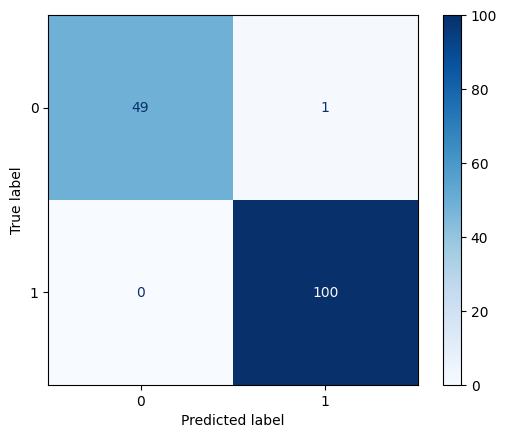

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()

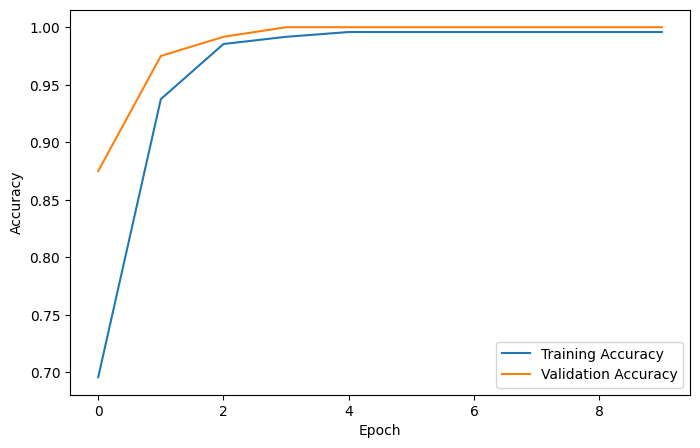

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

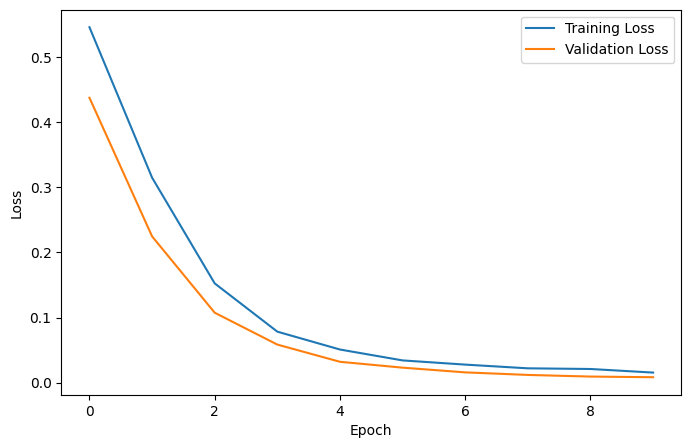

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [24]:
model.save("TierB_Glove_NN.keras")